In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

run = pickle.loads(Path(".run.pkl").read_bytes())
card, ev, constants = run["card"], run["evidence"], run["constants"]
gates = {g["number"]: g for g in run["gates"]}
pd.set_option("display.max_colwidth", None)
plt.rcParams.update({"figure.figsize": (9, 3), "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 9, "axes.titlesize": 10})
INK, GREY, MARK = "#1f4e79", "#a6a6a6", "#c0504d"


def text(value):
    return " ".join(str(value).split()) if value else "—"


def shown(value):
    if value is None:
        return "—"
    if isinstance(value, (list, tuple)):
        return "; ".join(map(str, value)) or "none"
    if isinstance(value, float):
        return float(f"{value:.4g}")
    return value


def table(figures):
    display(pd.Series({k: shown(v) for k, v in figures.items()}, dtype=object).to_frame().T.set_index(pd.Index([""])))


def gate(number):
    g = gates[number]
    reason = g["reason"].removeprefix("not computed: ")
    word = {True: "Passes", False: "Fails", None: "Not computed"}[g["passed"]]
    display(Markdown(f"**{word}**: {reason.rstrip('.')}."))
    if g["figures"]:
        table(g["figures"])


failed = run["failed"]
headline = ("passes gates 1 to 7" if failed is None
            else f"stops at gate {failed}, {gates[failed]['name'].lower()}: {gates[failed]['reason']}")
display(Markdown(f"# {card['id']}\n\nTheory **{card.get('theory', '—')}**. The battery's verdict: "
                 f"the strategy {headline}."))

# CA-015-01-average-correlation-timing

Theory **CA-015**. The battery's verdict: the strategy stops at gate 2, economic edge: Sharpe 0.430 against the benchmark's 0.500, alpha -0.29%; at twice the costs, Sharpe 0.424 and alpha -0.36%.

## Thesis

In [2]:
prediction = card.get("prediction") or {}
if isinstance(prediction, dict):
    prediction = ", ".join(f"{k}: {v}" for k, v in prediction.items())
display(Markdown(f"**Mechanism.** {text(card.get('mechanism'))}\n\n"
                 f"**Prediction.** {text(prediction)}\n\n"
                 f"**What would refute it.** {text(card.get('refuted_if'))}\n\n"
                 f"**Horizon.** {text(card.get('horizon'))}"))

**Mechanism.** The market's capacity to bear risk varies, and the premium it asks varies with it. When the components of a market move together -- high average correlation among them, typical of crises -- the common risk is what investors fear, they demand a higher premium for holding it, and the market's expected return over the next months is high; the market's variance mixes that part with the components' own variance, which predicts nothing or the reverse, so that volatility alone predicts little. Investors adjust their exposures to this slowly, so the reading, observed at a date, forecasts the market's return over the following quarter.

**Prediction.** sign: positive (the sector funds earn more over the month after their average correlation stood high against its past three years than after it stood low), size: a judgment -- Ilmanen reports Pollet and Wilson's finding of a correlation of 0.20 with future market returns (§8.6, horizon and sample not given there; the average correlation is not among Table 8.6's predictors), and chapter 19 gives the horizon, the next quarter, without a figure; read here as quarterly, about 0.1 over a month; at a monthly correlation of 0 to 0.1, a slope of about 0 to 2 percentage points of monthly excess return per unit of percentile, an appraisal ratio of about 0 to 0.35 against the sector funds held always and an alpha of about 0 to 2% a year before costs on a residual volatility of about 6% -- but a beta above the average share of 0.47, perhaps 0.5 to 0.7, since the share is highest when the sectors are most volatile, so that the hedged alpha may be below zero with a positive slope; costs about 0.1% a year; the base expected to fail gate 3 or gate 4

**What would refute it.** Judged on the base, computed apart from the battery after the run: over the in-sample months from the base's first target to December 2022, each month running from the close of its first session to the close of the next month's first session, the last month, December 2022, ending at the close of 2022-12-30, the sector funds that trade on the month's first session bought in equal parts at the close of that session and held without rebalancing, their return over the month less the Treasury bill's daily returns compounded over the same sessions, before costs, regressed by ordinary least squares on the base's percentile set on the month's first session, with a constant, the standard error robust to heteroskedasticity. The two months whose sector funds' return TM-024-01 published -- those whose first sessions fall in September 2010 and October 2022 -- are left out of the graded sample, and the slope with them is reported. The theory is refuted in this form if the slope is zero or less: the sector funds' average correlation, observed at a date, did not predict their market's return over the next month out of the sources' sample, as the bank's second refutation reads. Any other result short of the base passing gates 1 to 7 is not proven, not refuted; a base that passes gates 1 to 7 while the clause refutes leaves the theory refuted in this form. The first refutation, premia constant across regimes, is read by the same slope and not graded apart; the third, the predictability disappearing with crowding, is not graded: the lab holds no positions or flows. TM-024-01's 18 sector panic months (October 2008 to November 2009, July to September 2010, April 2020), whose market return it published pooled with the other groups' (its nineteen funds in equal parts earned 27.4% a year in the months its rule differed from CA-001-01's against 5.8% elsewhere), 15 of them (83%) with a percentile above 0.5, counted from the signal alone, under CA-003-01's 90%, stay in the graded sample, disclosed, and the slope without them is reported. The grade rests on the slope, not on the base's appraisal ratio, because the share is highest when the sectors are most volatile: the hedged alpha can fall below zero while the reading predicts. The published results of TM-047-02, TM-024-01, TM-039-01, TM-017-01, TM-018-01, CA-006-01, TM-037-01, TM-041-01, SC-026-01, CA-011-01, CA-014-01, TM-002-01 and LL-042-01, their years, states and holdings, and the registry's monthly hedged returns of TM-047-02 and CA-006-01, from which nothing was computed, stay, disclosed. Reported, not graded: the base's figures as the battery gives them; the variant's difference of the mean monthly excess return after readings above the median and after the others, with its standard error; the slope on the next 63 sessions' excess return, Pollet and Wilson's quarter, from every month's first session, the standard error corrected for the overlap (Newey and West, two lags); the slope on the percentile of the sector funds' average variance of daily returns over the same window and lookback, alone and with the correlation's percentile, Pollet and Wilson's other half, predicted negative or nil; the slope over 2008 to 2014 and 2015 to 2022; the slope in the holdout; the correlation of the base's monthly returns hedged of its benchmark with TM-047-02's base as the registry gives it, over their common months.

**Horizon.** months

## Data

In [3]:
x = ev.get("excess")
start, end = constants["in sample"]
cannot_run = gates[1]["reason"].startswith("the strategy cannot run")
broke = gates[1]["reason"].startswith("cannot be computed: ")        # the runs every gate judges broke
evaluated = (f"evaluated from the first session the strategy holds an asset, {x.index[0].date()}, to "
             f"{x.index[-1].date()}" if x is not None and len(x)
             else "not evaluated: the strategy cannot run" if cannot_run
             else f"not evaluated: the runs every gate judges broke ({gates[1]['reason'].split(': ', 1)[1]})"
             if broke else "not evaluated: nothing was held")
display(Markdown(
    f"Daily closes adjusted for dividends and splits, snapshot **{run['snapshot']}**. "
    f"Universe: {', '.join(card['universe'])}. In-sample {start} to {end}, {evaluated}; "
    f"holdout {' to '.join(constants['holdout'])}, opened once, at gate 7. "
    f"Returns are above the Treasury-bill rate, net of costs."))

Daily closes adjusted for dividends and splits, snapshot **2026-09-22+2026-09-23**. Universe: XLB, XLC, XLE, XLF, XLI, XLK, XLP, XLRE, XLU, XLV, XLY. In-sample 2005-01-01 to 2022-12-31, evaluated from the first session the strategy holds an asset, 2008-05-02, to 2022-12-30; holdout 2023-01-01 to 2025-12-31, opened once, at gate 7. Returns are above the Treasury-bill rate, net of costs.

## Signal

On every session, the reading is the average, over every pair of the sector funds that trade on that session and have window daily returns in the signal prices up to and including the session before, of the correlation of those window returns; there is no reading while fewer than two such funds exist. The reading's percentile is the share of the readings of the lookback sessions before it, up to and including the session before, that are at or below it; there is no percentile while any of those lookback readings is missing. On the first session of each month on which the percentile exists, under rule "scaled" each sector fund that trades holds the percentile divided by the number of sector funds trading, the rest in cash; under rule "median" each holds one over that number when the reading is above the median of the same lookback readings, and nothing otherwise, all in cash. No target on any other session, so that positions drift.

- **window**: daily returns over which each pair's correlation is measured, a quarter, the horizon of the forecast Ilmanen reports; the library gives no measurement window
- **lookback**: readings against which the reading is ranked, three years
- **rule**: "scaled" holds the sector funds in the proportion of the percentile, Cochrane's managed portfolio; "median" holds them all or none, Ilmanen's 1/0 model

,window,lookback,rule
base,63,756,scaled
variant 1,63,756,median


Parameter neighbours, moved one at a time for gate 6: window at ±25%: 47, 79; window at ±50%: 32, 94; lookback at ±25%: 567, 945; lookback at ±50%: 378, 1134.

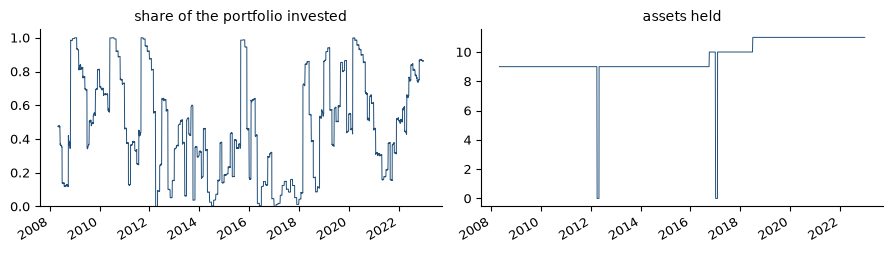

In [4]:
display(Markdown(text(card.get("signal"))))
parameters = card.get("parameters") or {}
if parameters:
    display(Markdown("\n".join(f"- **{k}**: {text(v)}" for k, v in parameters.items())))
variants = pd.DataFrame(card["variants"], index=["base"] + [f"variant {k}" for k in range(1, len(card["variants"]))])
display(variants)
neighbours = card.get("neighbours") or {}
if neighbours:
    display(Markdown("Parameter neighbours, moved one at a time for gate 6: "
                     + "; ".join(f"{p} at ±{step}%: {', '.join(map(str, values))}"
                                 for p, steps in neighbours.items() for step, values in steps.items()) + "."))
if "exposure" in ev:
    fig, (a, b) = plt.subplots(1, 2, figsize=(9, 2.6))
    ev["exposure"].plot(ax=a, color=INK, linewidth=0.7)
    a.set_title("share of the portfolio invested")
    a.set_ylim(0, 1.05)
    ev["assets held"].plot(ax=b, color=INK, linewidth=0.7)
    b.set_title("assets held")
    for axis in (a, b):
        axis.set_xlabel("")
    plt.tight_layout()

## Equity against the benchmark

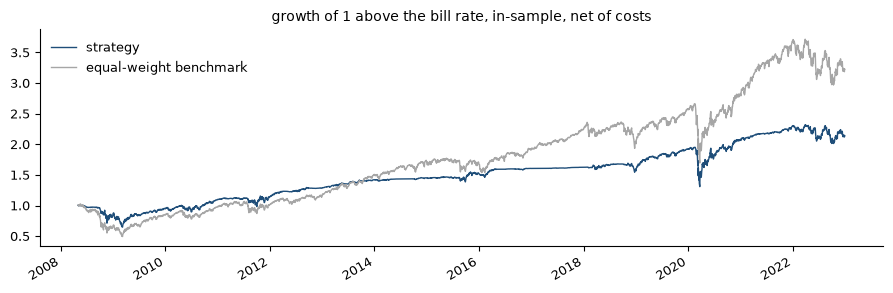

In [5]:
if x is not None and len(x):
    b = ev["benchmark excess"]
    fig, ax = plt.subplots()
    (1 + x).cumprod().plot(ax=ax, color=INK, linewidth=1, label="strategy")
    (1 + b).cumprod().plot(ax=ax, color=GREY, linewidth=1, label="equal-weight benchmark")
    ax.set_title("growth of 1 above the bill rate, in-sample, net of costs")
    ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.tight_layout()
else:
    display(Markdown("The strategy cannot run: there is no equity to draw." if cannot_run
                     else "The runs every gate judges broke: there is no equity to draw." if broke
                     else "Nothing was held in-sample: there is no equity to draw."))

## Gate 1 · Hygiene

Protects against look-ahead, bad data and too little evidence.

**Passes**: no look-ahead on 200 dates, 173 decisions over 14.7 years.

,dates checked,look-ahead breaks,same-day breaks,memory,memory dates checked,memory breaks,data problems,clustered decisions,years in-sample,years needed
,200,0,0,1240,100,0,none,173,14.66,5


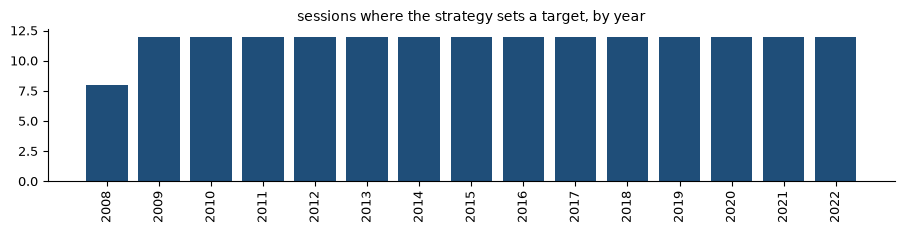

In [6]:
gate(1)
days = ev.get("target days")
if days is not None and len(days):
    per_year = pd.Series(1, index=days).groupby(days.year).sum()
    fig, ax = plt.subplots(figsize=(9, 2.4))
    ax.bar(per_year.index.astype(str), per_year, color=INK)
    breaks = sorted({d.year for variant in ev["timing breaks"].values() for kind in variant.values() for d in kind})
    for year in breaks:
        ax.bar(str(year), per_year.get(year, 0), color=MARK)
    ax.set_title("sessions where the strategy sets a target, by year" + ("; red: a timing break" if breaks else ""))
    ax.tick_params(axis="x", rotation=90)
    plt.tight_layout()

## Gate 2 · Economic edge

Protects against an edge explained by costs or by market exposure.

**Fails**: Sharpe 0.430 against the benchmark's 0.500, alpha -0.29%; at twice the costs, Sharpe 0.424 and alpha -0.36%.

,Sharpe,benchmark Sharpe,alpha,Sharpe at 2x costs,alpha at 2x costs,gross Sharpe,costs a year,costs in Sharpe units
,0.4298,0.4996,-0.002872,0.424,-0.003611,0.4355,0.000833,0.005722


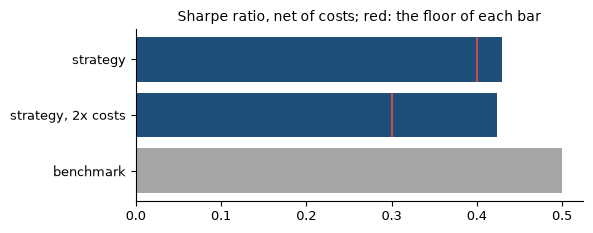

In [7]:
gate(2)
f = gates[2]["figures"]
if f:
    floors = constants["floors"]
    rows = [("benchmark", f["benchmark Sharpe"], GREY, None),
            ("strategy, 2x costs", f["Sharpe at 2x costs"], INK, floors["Sharpe at 2x costs"]),
            ("strategy", f["Sharpe"], INK, floors["Sharpe"])]
    fig, ax = plt.subplots(figsize=(6, 2.4))
    for y, (label, value, colour, floor) in enumerate(rows):
        ax.barh(y, value, color=colour)
        if floor is not None:
            ax.vlines(floor, y - 0.4, y + 0.4, color=MARK, linewidth=1.5)
    ax.set_yticks(range(len(rows)), [r[0] for r in rows])
    ax.set_title("Sharpe ratio, net of costs; red: the floor of each bar")
    plt.tight_layout()

## Gate 3 · Significance

Protects against luck, and against being paid only for being invested. A strategy that holds nearly every asset that trades is close to its benchmark: its placebos differ from it by little, details of the path decide its rank, and gates 2 and 4 judge it.

**Fails**: beats 42.7% of its shifted placebos, fewer than 90%.

,PSR,placebo sessions,placebos,placebos beaten
,0.9617,3694,1000,0.427


Assets that start trading after 2008-05-01: XLC, XLRE. A placebo shifts their weights only between days when they trade. Where it draws from a day before their start, it keeps their own weights; where it draws from a day after their start onto a day before it, the share it cannot hold yet takes the strategy's own weights of that day, and with them its timing: skill that lies before a late start is judged against placebos that share it, and is found less often. Where the strategy holds none of the assets shifted that day, the shifted weights take that share instead.

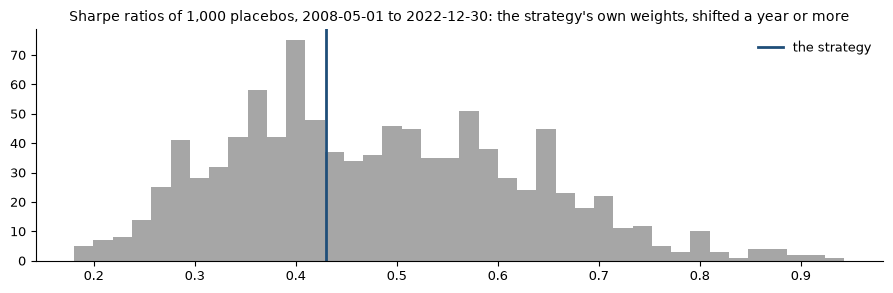

In [8]:
gate(3)
if "placebos" in ev:
    fig, ax = plt.subplots()
    ax.hist(ev["placebos"], bins=40, color=GREY)
    ax.axvline(ev["placebo own Sharpe"], color=INK, linewidth=2, label="the strategy")
    first, last = (d.date() for d in ev["placebo window"])
    ax.set_title(f"Sharpe ratios of {len(ev['placebos']):,} placebos, {first} to {last}: the strategy's own weights, "
                 f"shifted a year or more")
    ax.legend(frameon=False)
    plt.tight_layout()
    if ev.get("placebo late assets"):
        display(Markdown(f"Assets that start trading after {first}: {', '.join(ev['placebo late assets'])}. A placebo "
                         f"shifts their weights only between days when they trade. Where it draws from a day before their "
                         f"start, it keeps their own weights; where it draws from a day after their start onto a day before "
                         f"it, the share it cannot hold yet takes the strategy's own weights of that day, and with them its "
                         f"timing: skill that lies before a late start is judged against placebos that share it, and is "
                         f"found less often. Where the strategy holds none of the assets shifted that day, the shifted "
                         f"weights take that share instead."))

## Gate 4 · Multiple testing

Protects against the best of many tries: the edge, hedged of the benchmark, deflated by every trial the registry holds.

**Fails**: DSR 0.005 below 0.9 over 71 effective trials.

,trials,effective trials,appraisal ratio,Sharpe expected by luck,DSR
,78,71,-0.0452,0.6289,0.004635


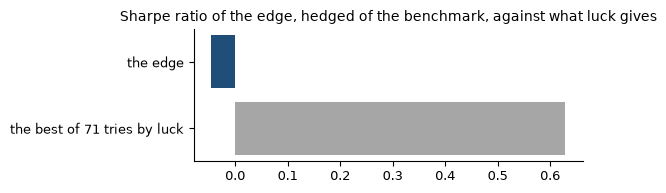

In [9]:
gate(4)
f = gates[4]["figures"]
if f and "appraisal ratio" in f:
    fig, ax = plt.subplots(figsize=(6, 2.0))
    ax.barh([0, 1], [f["Sharpe expected by luck"], f["appraisal ratio"]], color=[GREY, INK])
    tries = f["effective trials"]
    ax.set_yticks([0, 1], [f"the best of {tries} {'try' if tries == 1 else 'tries'} by luck", "the edge"])
    ax.set_title("Sharpe ratio of the edge, hedged of the benchmark, against what luck gives")
    plt.tight_layout()

## Gate 5 · Stability

Protects against an edge that lives in one variant or one episode.

**Fails**: the blend of the variants fails gates 2, 3 and 4; alpha -1.34% without its best year, 2008.

,blend passes gate 2,blend passes gate 3,blend passes gate 4,worst variant Sharpe,positive blocks,best year,alpha without the best year
,False,False,False,0.4298,3,2008,-0.01343


The blend of the variants: gate 2, Sharpe 0.484 against the benchmark's 0.500, alpha 0.85%; gate 3, beats 58.7% of its shifted placebos, fewer than 90%; gate 4, DSR 0.026 below 0.9 over 71 effective trials.

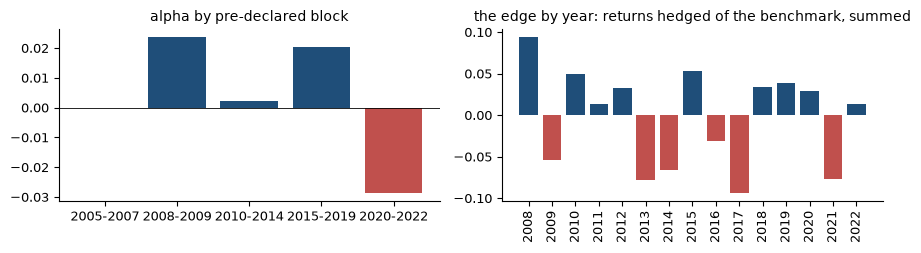

In [10]:
gate(5)
if "blocks" in ev:
    fig, (a, c) = plt.subplots(1, 2, figsize=(9, 2.6))
    blocks = pd.Series({k: (v if v is not None else np.nan) for k, v in ev["blocks"].items()})
    a.bar(blocks.index, blocks.fillna(0), color=[INK if v > 0 else MARK for v in blocks.fillna(0)])
    a.set_title("alpha by pre-declared block")
    a.axhline(0, color="black", linewidth=0.6)
    by_year = ev["edge by year"]
    c.bar(by_year.index.astype(str), by_year, color=[INK if v > 0 else MARK for v in by_year])
    c.set_title("the edge by year: returns hedged of the benchmark, summed")
    c.tick_params(axis="x", rotation=90)
    plt.tight_layout()
failed_blend = {n: reason for n, reason in ev.get("blend", {}).items() if gates[5]["figures"].get(f"blend passes gate {n}") is False}
if failed_blend:
    display(Markdown("The blend of the variants: " + "; ".join(f"gate {n}, {r}" for n, r in failed_blend.items()) + "."))

## Gate 6 · Robustness

Protects against a peak, one asset, timing too tight and a clone.

**Passes**: neighbours, clusters, assets, bitcoin, delay and survivors all hold.

,neighbour median ratio,lowest ±25% ratio,neighbours that hold the base,worst cluster out,worst cluster out ratio,largest P&L share,asset with the largest share,one day late ratio,highest correlation with a survivor,survivor most correlated
,0.9987,0.9434,none,—,—,0.1509,XLK,0.9777,—,—


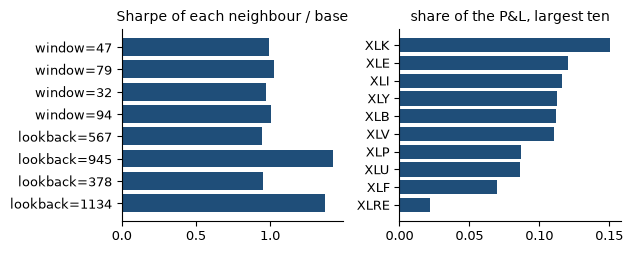

In [11]:
gate(6)
panels = [(k, ev.get(k)) for k in ("neighbours", "clusters out", "P&L shares") if ev.get(k) is not None and len(ev.get(k))]
if panels:
    fig, axes = plt.subplots(1, len(panels), figsize=(3.2 * len(panels), 2.6))
    for axis, (name, values) in zip(np.atleast_1d(axes), panels):
        values = pd.Series(values).head(10)
        axis.barh(values.index.astype(str), values, color=INK)
        axis.set_title({"neighbours": "Sharpe of each neighbour / base", "clusters out": "Sharpe without a cluster / base",
                        "P&L shares": "share of the P&L, largest ten"}[name])
        axis.invert_yaxis()
    plt.tight_layout()
if ev.get("without bitcoin"):
    display(Markdown("Without bitcoin, gate 2's figures:"))
    table(ev["without bitcoin"])

## Gate 7 · Sealed holdout

Protects against bugs and large decay, on years kept aside and opened once.

**Passes**: holdout Sharpe 1.27 and alpha 3.57%, both above the in-sample 10th percentile.

,holdout Sharpe,Sharpe floor,holdout alpha,alpha floor,variants rewritten,dates checked,look-ahead breaks,same-day breaks,data problems
,1.273,-0.1644,0.03575,-0.04256,0,40,0,0,none


Red: the 10th percentile of the in-sample paths, the floor; blue: the holdout.

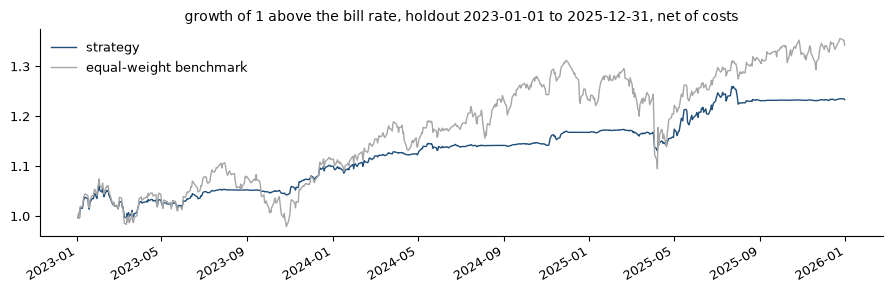

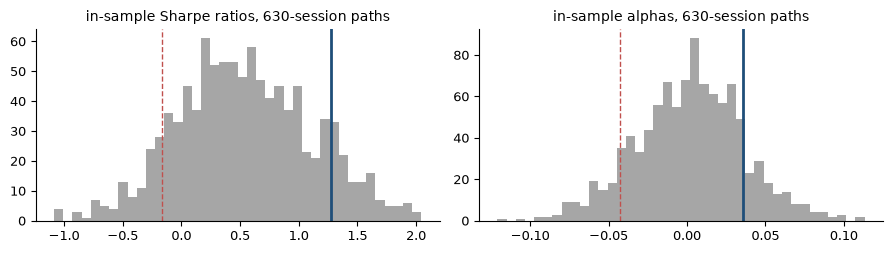

In [12]:
gate(7)
f = gates[7]["figures"]
if "holdout excess" in ev and len(ev["holdout excess"]):
    fig, ax = plt.subplots()
    (1 + ev["holdout excess"]).cumprod().plot(ax=ax, color=INK, linewidth=1, label="strategy")
    (1 + ev["holdout benchmark excess"]).cumprod().plot(ax=ax, color=GREY, linewidth=1, label="equal-weight benchmark")
    ax.set_title(f"growth of 1 above the bill rate, holdout {' to '.join(constants['holdout'])}, net of costs")
    ax.set_xlabel("")
    ax.legend(frameon=False)
    plt.tight_layout()
if "bootstrap" in ev and f:
    pct = constants["percentile"]
    fig, (a, c) = plt.subplots(1, 2, figsize=(9, 2.6))
    for axis, key, mark, label in ((a, "Sharpe", "holdout Sharpe", "Sharpe ratio"), (c, "alpha", "holdout alpha", "alpha")):
        axis.hist(ev["bootstrap"][key], bins=40, color=GREY)
        axis.axvline(np.percentile(ev["bootstrap"][key], pct), color=MARK, linestyle="--", linewidth=1)
        axis.axvline(f[mark], color=INK, linewidth=2)
        axis.set_title(f"in-sample {label}s, {constants['window']}-session paths")
    plt.tight_layout()
    display(Markdown(f"Red: the {pct}th percentile of the in-sample paths, the floor; blue: the holdout."))

## Verdict

In [13]:
table = pd.DataFrame([{"gate": f"{g['number']} · {g['name']}",
                       "result": {True: "passes", False: "fails", None: "not computed"}[g["passed"]],
                       "reason": g["reason"].removeprefix("not computed: ")} for g in run["gates"]]).set_index("gate")
display(table)
display(Markdown(f"Thresholds, version {run['thresholds']}. What the verdict means for the theory, and what was "
                 f"learned, is written in [verdict.md](verdict.md)."))

,result,reason
gate,,
1 · Hygiene,passes,"no look-ahead on 200 dates, 173 decisions over 14.7 years"
2 · Economic edge,fails,"Sharpe 0.430 against the benchmark's 0.500, alpha -0.29%; at twice the costs, Sharpe 0.424 and alpha -0.36%"
3 · Significance,fails,"beats 42.7% of its shifted placebos, fewer than 90%"
4 · Multiple testing,fails,DSR 0.005 below 0.9 over 71 effective trials
5 · Stability,fails,"the blend of the variants fails gates 2, 3 and 4; alpha -1.34% without its best year, 2008"
6 · Robustness,passes,"neighbours, clusters, assets, bitcoin, delay and survivors all hold"
7 · Sealed holdout,passes,"holdout Sharpe 1.27 and alpha 3.57%, both above the in-sample 10th percentile"


Thresholds, version 4. What the verdict means for the theory, and what was learned, is written in [verdict.md](verdict.md).